# 8.1 Conflict Monitoring

Humans are motivationally omnivorous -- from wanting to catch a fish to wanting to walk on the moon. Accomplishing open-ended goals that can span days to lifetimes requires ... did you just get an email notification? Go ahead, check your phone, this notebook is very patient... now you're back ... requires a cognitive architecture capable of overcoming interruptions, sustaining effort, and controlling attention. These abilities comprise the will of free will.

Around the start of the semester, you freely decided to learn about computational modeling of psychological function, and for the most part have willfully followed through. At times it has been effortless -- when you were captivated by fascinating discoveries, theories, and models. At other times it has been effortful -- requiring you to suppress a wide variety of distractions and competing interests. During those effortful moments, when you succeeded in maintaining or regaining focus on the lectures, readings, or lab work, what was happening in your mind? In this lab, we will explore the cognitive processes that monitor for internal conflict and help overcome that conflict. When effort is required to help control attention, mechanisms that monitor conflict can activate effort and control. For a familiar starting point, we will build a conflict monitoring system on top of a Stroop model introduced in the last chapter (see 7.1).

*Setup and Installation:*

In [2]:
%%capture
%pip install psyneulink
%pip install stroop

import psyneulink as pnl


## The Stroop Model

First, we reimplement the stroop model from chapter 7.

In [4]:
INTEGRATION_RATE = .2
UNIT_NOISE_STD = .01
DEC_NOISE_STD = .1
LEAK = 0
COMPETITION = 1

def get_stroop(
        integration_rate=INTEGRATION_RATE,
        unit_noise_std=UNIT_NOISE_STD,
        dec_noise_std=DEC_NOISE_STD,
        leak=LEAK,
        competition=COMPETITION,
):
    # Input units
    color_inp = pnl.TransferMechanism(name='Color Input', default_variable=[0, 0])
    word_inp = pnl.TransferMechanism(name='Word Input', default_variable=[0, 0])
    task_demand = pnl.TransferMechanism(name='Task Demand', default_variable=[0, 0])
    
    # Hidden units
    color_hidden = pnl.TransferMechanism(
        default_variable=[0, 0],
        function=pnl.Logistic(gain=1., bias=-4.),
        integrator_mode=True,
        integration_rate=INTEGRATION_RATE,
        noise=pnl.NormalDist(standard_deviation=UNIT_NOISE_STD).function,
        name='Color hidden')

    word_hidden = pnl.TransferMechanism(
        default_variable=[0, 0],
        function=pnl.Logistic(gain=1., bias=-4.),
        integrator_mode=True,
        integration_rate=INTEGRATION_RATE,
        noise=pnl.NormalDist(standard_deviation=UNIT_NOISE_STD).function,
        name='Word hidden')

    # Output units 
    output = pnl.TransferMechanism(
        default_variable=[0, 0],
        function=pnl.Logistic,
        integrator_mode=True,
        integration_rate=INTEGRATION_RATE,
        noise=pnl.NormalDist(standard_deviation=UNIT_NOISE_STD).function,
        name='Output')

    
    # Decision layer
    decision = pnl.LCAMechanism(
        default_variable=[0, 0],
        leak=LEAK,
        competition=COMPETITION,
        noise=pnl.UniformToNormalDist(standard_deviation=DEC_NOISE_STD).function,
        name='Decision'
    )

    # Projections
    
    # Input to hidden
    wts_clr_ih = pnl.MappingProjection(
        matrix=[[2.2, -2.2], [-2.2, 2.2]], name='Color input to hidden')
    
    wts_wrd_ih = pnl.MappingProjection(
        matrix=[[2.6, -2.6], [-2.6, 2.6]], name='Word input to hidden')
    
    # Task demand to hidden
    wts_tc = pnl.MappingProjection(
        matrix=[[4.0, 4.0], [0, 0]], name='Color naming')
    
    wts_tw = pnl.MappingProjection(
        matrix=[[0, 0], [4.0, 4.0]], name='Word reading')
    
    # Hidden to response
    wts_clr_r = pnl.MappingProjection(
        matrix=[[1.3, -1.3], [-1.3, 1.3]], name='Color hidden to Output')
    wts_wrd_r = pnl.MappingProjection(
        matrix=[[2.5, -2.5], [-2.5, 2.5]], name='Word hidden to Output')
    
    # build the model
    model = pnl.Composition(name='Complex Stroop')
    
    # pathways
    model.add_linear_processing_pathway([color_inp, wts_clr_ih, color_hidden])
    model.add_linear_processing_pathway([word_inp, wts_wrd_ih, word_hidden])
    model.add_linear_processing_pathway([task_demand, wts_tc, color_hidden])
    model.add_linear_processing_pathway([task_demand, wts_tw, word_hidden])
    model.add_linear_processing_pathway([color_hidden, wts_clr_r, output])
    model.add_linear_processing_pathway([word_hidden, wts_wrd_r, output])
    model.add_linear_processing_pathway([output, pnl.IDENTITY_MATRIX, decision])
    
    # collect the node handles
    nodes = {'color_inp': color_inp,
            'word_inp': word_inp,
            'task_demand': task_demand,
            'color_hidden': color_hidden,
            'word_hidden': word_hidden,
            'output': output,
            'decision': decision}
    
    # collect the metadata
    metadata = {
        'integration_rate': integration_rate,
        'dec_noise_std': dec_noise_std,
        'unit_noise_std': unit_noise_std,
        'leak': leak,
        'competition': competition
    }
    
    return model, nodes, metadata

Let's get a model without noise:

In [5]:
# define the model
model, nodes, model_params = get_stroop(unit_noise_std=0, dec_noise_std=0)

And look at it:

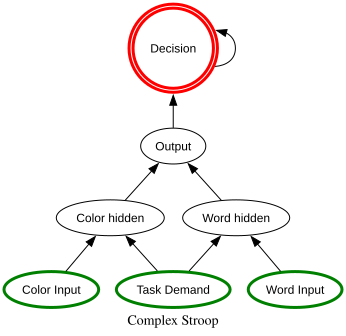

In [6]:
model.show_graph(output_fmt='jupyter')

Let's also get a stimulus set:

In [7]:
from stroop.stimulus import get_stimulus_set, TASKS, COLORS, CONDITIONS

# get the input nodes
inp_color = nodes['color_inp']
inp_word = nodes['word_inp']
inp_task = nodes['task_demand']

# the length of the stimulus sequence
n_time_steps = 120
input_set = get_stimulus_set(
    inp_color, inp_word, inp_task, n_time_steps)

# show what's in the dictionary
for task in TASKS:
    print(f'{task}: {input_set[task].keys()}')

color naming: dict_keys(['control', 'conflict', 'congruent'])
word reading: dict_keys(['control', 'conflict', 'congruent'])


In [8]:
# show one stimuli sequence
task = 'color naming'
cond = 'conflict'
print(input_set[task][cond][inp_color].T)

[[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
  1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
  1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
  1 1 1 1 1 1 1 1 1 1 1 1]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0]]
